In [17]:
import numpy as np
import torch 
import matplotlib.pyplot as plt


In [18]:
data = np.genfromtxt('./data/titanic_modified_dataset.csv',delimiter=',',skip_header=1)
X=torch.from_numpy(data[:,1:-1]).float()
y=torch.from_numpy(data[:,-1:]).float()
X,y

(tensor([[ 3.0000,  0.0000, 22.0000,  ...,  7.2500,  0.0000,  0.0000],
         [ 1.0000,  1.0000, 38.0000,  ..., 71.2833,  1.0000,  1.0000],
         [ 3.0000,  1.0000, 26.0000,  ...,  7.9250,  0.0000,  2.0000],
         ...,
         [ 3.0000,  1.0000, 28.0000,  ..., 23.4500,  0.0000,  2.0000],
         [ 1.0000,  0.0000, 26.0000,  ..., 30.0000,  1.0000,  0.0000],
         [ 3.0000,  0.0000, 32.0000,  ...,  7.7500,  2.0000,  0.0000]]),
 tensor([[0.],
         [1.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [1.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [1.],
   

In [19]:
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True)
X = (X - X_mean) / (X_std + 1e-8)

In [20]:
class logistic(torch.nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim,1)
    
    def forward(self,x):
        z=self.linear(x)
        y_hat=torch.sigmoid(z)
        return y_hat

model = logistic(8)
print(model)

logistic(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [21]:
criterion = torch.nn.BCELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

In [22]:
num_epochs=1000
losses = []

for epoch in range(num_epochs):
    y_hat = model(X)
    loss = criterion(y_hat,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

Epoch 100/1000, Loss: 0.6081
Epoch 200/1000, Loss: 0.5533
Epoch 300/1000, Loss: 0.5209
Epoch 400/1000, Loss: 0.5004
Epoch 500/1000, Loss: 0.4867
Epoch 600/1000, Loss: 0.4770
Epoch 700/1000, Loss: 0.4700
Epoch 800/1000, Loss: 0.4647
Epoch 900/1000, Loss: 0.4605
Epoch 1000/1000, Loss: 0.4572


In [23]:
model.eval()  # Chuyển sang evaluation mode
with torch.no_grad():
    # Dự đoán
    y_pred = model(X)
    
    # Chuyển xác suất thành class (0 hoặc 1)
    y_pred_class = (y_pred >= 0.5).float()
    
    # Tính accuracy
    correct = (y_pred_class == y).sum().item()
    accuracy = correct / len(y) * 100
    
    print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 79.01%


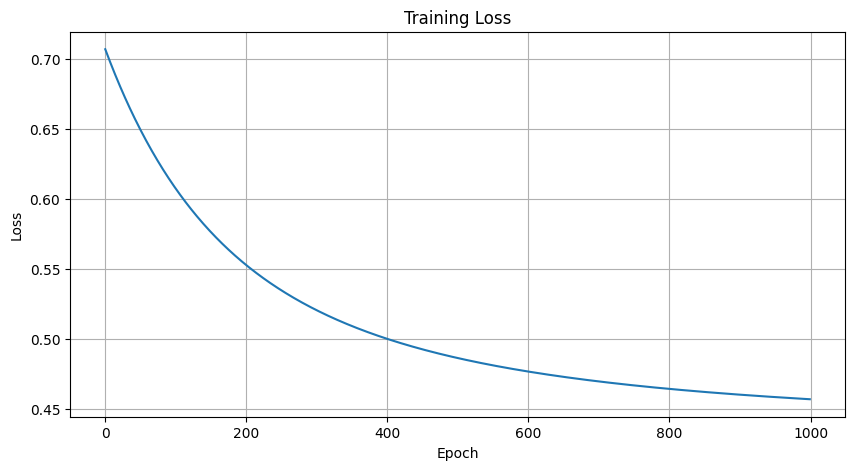

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()